In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("leonidkiselev/football-matches-statistics")

print("Path to dataset files:", path)

100%|██████████| 11.0M/11.0M [00:02<00:00, 4.47MB/s]

Extracting files...


Path to dataset files: C:\Users\M. Grillo\.cache\kagglehub\datasets\leonidkiselev\football-matches-statistics\versions\2


ist 2014 bis 2022

Zeilen im Spieler-DF: 640501
Zeilen im kombinierten DF: 640501


array(['DC', 'DL', 'DR', 'FW', 'GK', 'MC', 'ML', 'MR', 'Sub', 'FWL',
       'FWR', 'AMC', 'DMC', 'AML', 'AMR', 'DML', 'DMR'], dtype=object)

In [3]:
import pandas as pd

df = pd.read_csv("./dataset/football_matches_dataset.csv")
dfc = pd.read_csv("./dataset/ratings.csv")

df.info()
df.shape
df.head(4)
#df.describe()
#df.home_team.head(58)
#df.league.unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16332 entries, 0 to 16331
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                16332 non-null  int64  
 1   home_team                                 16332 non-null  object 
 2   away_team                                 16332 non-null  object 
 3   date                                      16332 non-null  object 
 4   league                                    16332 non-null  object 
 5   season                                    16332 non-null  object 
 6   home_score                                16332 non-null  int64  
 7   away_score                                16332 non-null  int64  
 8   home_xg                                   16332 non-null  float64
 9   away_xg                                   16332 non-null  float64
 10  datetime                          

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import pandas as pd

# 1. Daten einlesen
df_matches = df
df_players = dfc

# 2. Schlüsselspalten definieren
# Da die Spaltennamen in beiden Heads exakt übereinstimmen (home_team, away_team, season),
# können wir sie direkt als Liste übergeben.
merge_keys = ['home_team', 'away_team', 'season']
df_matches_bl = df_matches[df_matches['league'] == 'Bundesliga'].iloc[:, :12].copy()

# 3. Zusammenführen (Left-Merge an die Spieler-Statistiken)
df_combined = pd.merge(
    df_players, 
    df_matches, 
    on=merge_keys, 
    how='inner'
)

# Kontroll-Check
print(f"Zeilen im Spieler-DF: {len(df_players)}")
print(f"Zeilen im kombinierten DF: {len(df_combined)}")

df_combined.head(35)

df_combined.iloc[72:73].match_url
df_players.position.unique()


Zeilen im Spieler-DF: 640501
Zeilen im kombinierten DF: 640501


array(['DC', 'DL', 'DR', 'FW', 'GK', 'MC', 'ML', 'MR', 'Sub', 'FWL',
       'FWR', 'AMC', 'DMC', 'AML', 'AMR', 'DML', 'DMR'], dtype=object)

In [10]:
df_matches_bl = df_matches[df_matches['league'] == 'Bundesliga'].iloc[:, :33]
df_matches_bl


,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_goals_against_last_4_matches,away_goals_against_last_4_matches,home_goals_against_last_2_home_matches,away_goals_against_last_2_away_matches,home_mean_xg_last_4_matches,away_mean_xg_last_4_matches,home_mean_xg_last_2_home_matches,away_mean_xg_last_2_away_matches,home_mean_xg_against_last_4_matches,away_mean_xg_against_last_4_matches
30,30,Bayern Munich,Wolfsburg,August 22 2014,Bundesliga,2014/2015,2,1,2.57,1.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,34,Borussia Dortmund,Bayer Leverkusen,August 23 2014,Bundesliga,2014/2015,0,2,0.48,1.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,37,Eintracht Frankfurt,Freiburg,August 23 2014,Bundesliga,2014/2015,1,0,1.75,1.38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,39,FC Cologne,Hamburger SV,August 23 2014,Bundesliga,2014/2015,0,0,0.52,0.91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,42,Hannover 96,Schalke 04,August 23 2014,Bundesliga,2014/2015,2,1,1.18,0.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16260,16260,FC Cologne,Bayern Munich,May 27 2023,Bundesliga,2022/2023,1,2,1.16,1.68,...,5.0,4.0,3.0,4.0,2.275,2.9125,3.105,2.360,1.2950,0.9675
16268,16268,RasenBallsport Leipzig,Schalke 04,May 27 2023,Bundesliga,2022/2023,4,2,2.97,1.22,...,2.0,11.0,1.0,8.0,2.010,1.4675,1.755,1.745,0.7950,2.2275
16275,16275,Union Berlin,Werder Bremen,May 27 2023,Bundesliga,2022/2023,1,0,0.78,0.40,...,7.0,7.0,2.0,4.0,1.050,1.3600,1.015,1.330,1.5350,1.7325
16276,16276,VfB Stuttgart,Hoffenheim,May 27 2023,Bundesliga,2022/2023,1,1,2.19,1.16,...,5.0,6.0,2.0,3.0,1.665,1.4000,2.085,0.490,1.4375,1.6925


In [11]:
q1 = df.home_xg.quantile(0.25)
q2 = df.home_xg.quantile(0.50) 
q3 = df.home_xg.quantile(0.75)

print(q1)
print(q2)
print(q3)

0.85
1.36
2.03


In [12]:
q1 = df.away_xg.quantile(0.25)
q2 = df.away_xg.quantile(0.50) 
q3 = df.away_xg.quantile(0.75)

print(q1)
print(q2)
print(q3)

0.6
1.05
1.62


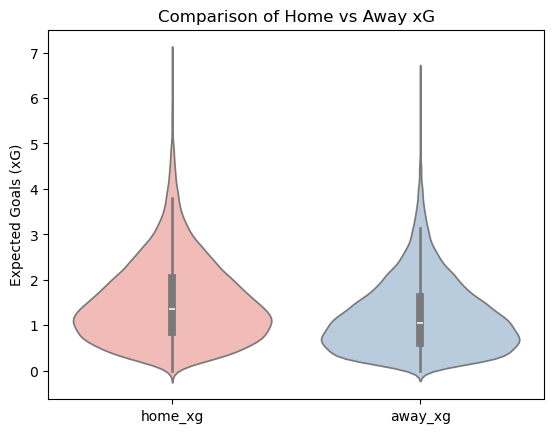

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

##sns.pairplot(df, vars=['home_xg', 'away_xg'], kind='scatter', height=5)
#sns.boxplot(x='away_xg', data=df, orient='h')
sns.boxplot(data=df[["home_xg", "away_xg"]], palette="Pastel1")

plt.close('all')
datam=df[["home_xg", "away_xg"]]
datam.head()
sns.violinplot(data=datam, palette="Pastel1")


plt.close('all')

# 2. Zwei UNTERSCHIEDLICHE Spalten auswählen
datam = df[["home_xg", "away_xg"]]

# 3. Plotten
sns.violinplot(data=datam, palette="Pastel1")

# 4. Plot explizit anzeigen lassen
plt.title("Comparison of Home vs Away xG")
plt.ylabel("Expected Goals (xG)")
plt.show()


In [36]:
df_matches_l1 = df_matches[df_matches['league'] == 'Ligue 1']

In [39]:
df_matches_bl = df_matches[df_matches['league'] == 'Bundesliga']
df_matches_la = df_matches[df_matches['league'] == 'La Liga']
df_matches_pl = df_matches[df_matches['league'] == 'EPL']
df_matches_sa = df_matches[df_matches['league'] == 'Serie A']


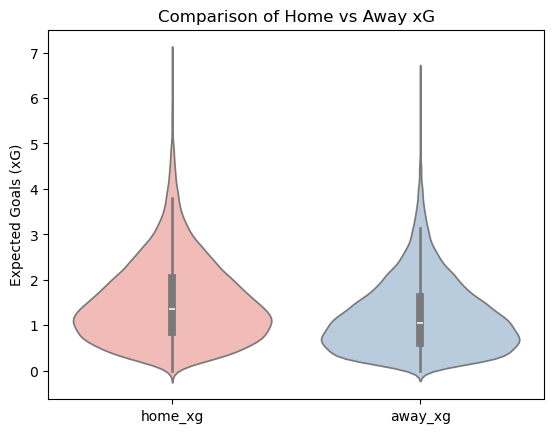

In [52]:
datam = df[["home_xg", "away_xg"]]
#.concat([df_matches_bl[["home_xg", "away_xg"]]], axis=0)
#                                           , df_matches_la[["home_xg", "away_xg"]], df_matches_pl[["home_xg", "away_xg"]], df_matches_sa[["home_xg", "away_xg"]]], ignore_index=True)

# 3. Plotten
sns.violinplot(data=datam, palette="Pastel1")

# 4. Plot explizit anzeigen lassen
plt.title("Comparison of Home vs Away xG")
plt.ylabel("Expected Goals (xG)")
plt.show()


In [38]:
df_matches.league.unique()

array(['Ligue 1', 'EPL', 'Bundesliga', 'La liga', 'Serie A'], dtype=object)

In [53]:
 df.head()

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape
df.info()
df.dtypes
df.nunique()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16332 entries, 0 to 16331
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                16332 non-null  int64  
 1   home_team                                 16332 non-null  object 
 2   away_team                                 16332 non-null  object 
 3   date                                      16332 non-null  object 
 4   league                                    16332 non-null  object 
 5   season                                    16332 non-null  object 
 6   home_score                                16332 non-null  int64  
 7   away_score                                16332 non-null  int64  
 8   home_xg                                   16332 non-null  float64
 9   away_xg                                   16332 non-null  float64
 10  datetime                          

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
count,16332.000000,16332,16332,16332,16332,16332,16332.000000,16332.000000,16332.000000,16332.000000,...,16018.000000,16018.000000,16020.000000,16016.000000,16018.000000,16018.000000,16020.000000,16016.000000,16018.000000,16018.000000
unique,NaN,157,157,1655,5,9,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Barcelona,Napoli,December 22 2018,EPL,2014/2015,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,171,171,37,3420,1826,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8165.500000,NaN,NaN,NaN,NaN,NaN,1.537595,1.213079,1.519489,1.198238,...,6.850295,6.758092,6.876918,6.892891,6.967077,6.803555,6.936985,6.952650,7.040911,6.848876
std,4714.786634,NaN,NaN,NaN,NaN,NaN,1.310895,1.166409,0.898103,0.791728,...,0.341491,0.352362,0.302985,0.304563,0.387721,0.372287,0.413593,0.415172,0.546994,0.506123
min,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,5.368333,5.333167,5.952500,5.925833,5.615000,5.570833,5.796250,5.857500,5.660000,5.545000
25%,4082.750000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.850000,0.600000,...,6.617000,6.524000,6.665625,6.681667,6.693333,6.542500,6.638750,6.660729,6.648333,6.480000
50%,8165.500000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.360000,1.050000,...,6.852750,6.754250,6.850000,6.866875,6.938125,6.776667,6.887500,6.901250,6.977500,6.777500
75%,12248.250000,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,2.030000,1.620000,...,7.084833,7.000000,7.063333,7.078000,7.211667,7.027500,7.175417,7.189167,7.355625,7.146458


In [35]:
df_num = df.select_dtypes(include=['number'])
df_num.columns

df_cat = df.select_dtypes(exclude=['number'])
df_cat.columns

#df.describe(include='all')


Index(['home_team', 'away_team', 'date', 'league', 'season', 'datetime'], dtype='object')

In [ ]:
df_cat['date'] = pd.to_datetime(df['date'], format='%B %d %Y')

df_cat.info()
df_cat.head(5)

df_cat.info()

df_cat.head(5)


away xg
count    16332.000000
mean         1.198238
std          0.791728
min          0.000000
25%          0.600000
50%          1.050000
75%          1.620000
max          6.500000
Name: away_xg, dtype: float64
home xg


count    16332.000000
mean         1.519489
std          0.898103
min          0.000000
25%          0.850000
50%          1.360000
75%          2.030000
max          6.880000
Name: home_xg, dtype: float64

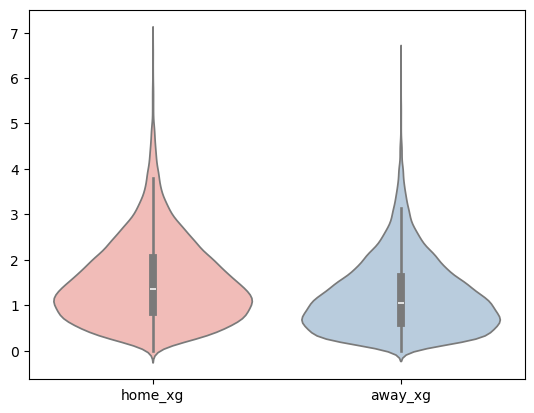

In [44]:
df.shape
#df.duplicated().sum()
#df.nunique()
#df.dtypes
import seaborn as sns

datam = df[["home_xg", "away_xg"]]
sns.violinplot(data=datam, palette="Pastel1")
#plt.title("Comparison of Home vs Away xG")
#plt.ylabel("Expected Goals (xG)")
#plt.show()


print("away xg")
print(df.away_xg.describe())
print("home xg")
df.home_xg.describe()


* _df.shape_
(16332, 55)

--> we got 16332 rows which is matches here described with 55 columns

* _df.duplicated().sum()_
np.int64(0)

--> 0 duplicates
* _df.dtypes_

--> datetime and date is of type object

* _df.nunique()_

--> 5 leagues, 9 seasons, 157 teams, 1655 match days

These numerical columns are "kind of" categorical:


    home_score                                     11
    away_score                                     10
    ...
    home_points_last_2_home_matches                 6
    away_points_last_2_away_matches                 6
    ...
    home_points_last_4_matches                     12
    away_points_last_4_matches                     12
    ...
    home_formation                                  5
    away_formation                                  5
    ...
    home_standings                                 20
    away_standings                                 20
    home_points                                    94
    away_points                                    97
    ...
    home_xg                                       519
    away_xg                                       454
    ...
    home_goals_last_4_matches                      22
    away_goals_last_4_matches                      22
    home_goals_last_2_home_matches                 15
    away_goals_last_2_away_matches                 14
    home_goals_against_last_4_matches              20
    away_goals_against_last_4_matches              20
    home_goals_against_last_2_home_matches         13
    away_goals_against_last_2_away_matches         14
    